# ECG Anomaly Detection — SMOTE + TFLite Edge Export
**Dataset:** [MIT-BIH on Kaggle](https://www.kaggle.com/datasets/shayanfazeli/heartbeat)

Pipeline:
1. Load MIT-BIH CSVs from Kaggle input path
2. Balance classes with SMOTE
3. Train a lightweight 1D CNN
4. Evaluate performance
5. Convert to TFLite + Int8 quantization for edge deployment

## 0. Install Dependencies

In [1]:
# Kaggle already has TF, sklearn, seaborn pre-installed.
# Only imbalanced-learn needs to be added.
!pip install -q imbalanced-learn

## 1. Load Dataset
The dataset used is **shayanfazeli/heartbeat** on Kaggle. 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Kaggle datasets are mounted at /kaggle/input/<dataset-slug>/
DATA_DIR = "/kaggle/input/datasets/shayanfazeli/heartbeat"

train_df = pd.read_csv(os.path.join(DATA_DIR, "mitbih_train.csv"), header=None)
test_df  = pd.read_csv(os.path.join(DATA_DIR, "mitbih_test.csv"),  header=None)

print(f"Train shape: {train_df.shape}  |  Test shape: {test_df.shape}")
train_df.head()

Train shape: (87554, 188)  |  Test shape: (21892, 188)


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Prepare Data

In [3]:
X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values

X_test  = test_df.iloc[:, :-1].values
y_test  = test_df.iloc[:, -1].values

# Binary classification: 0 = Normal, 1 = Anomaly
y_train = np.where(y_train == 0, 0, 1)
y_test  = np.where(y_test  == 0, 0, 1)

print("Class distribution before SMOTE:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls}: {cnt:,} samples ({cnt/len(y_train)*100:.1f}%)")

Class distribution before SMOTE:
  Class 0: 72,471 samples (82.8%)
  Class 1: 15,083 samples (17.2%)


## 3. Apply SMOTE
SMOTE generates synthetic minority-class (anomaly) samples by interpolating between existing ones in feature space.
**Rule:** fit SMOTE only on training data — the test set must stay as-is.

Class distribution after SMOTE:
  Class 0: 72,471 samples (50.0%)
  Class 1: 72,471 samples (50.0%)


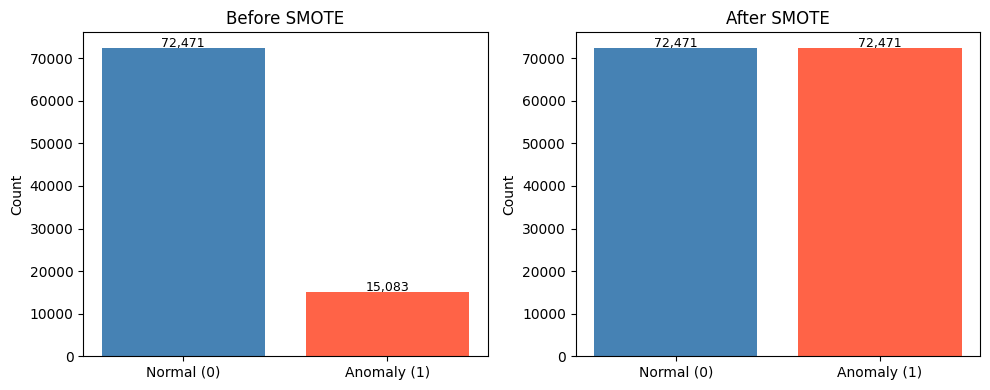

In [4]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:")
unique, counts = np.unique(y_train_sm, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls}: {cnt:,} samples ({cnt/len(y_train_sm)*100:.1f}%)")

# Visualise before vs after
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
orig_counts  = np.bincount(y_train)
smote_counts = np.bincount(y_train_sm)

for ax, counts_data, title in zip(
    axes,
    [orig_counts, smote_counts],
    ['Before SMOTE', 'After SMOTE']
):
    ax.bar(['Normal (0)', 'Anomaly (1)'], counts_data, color=['steelblue', 'tomato'])
    ax.set_title(title); ax.set_ylabel('Count')
    for i, v in enumerate(counts_data):
        ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 4. Reshape for 1D CNN

In [5]:
X_train_sm = X_train_sm.reshape(X_train_sm.shape[0], 187, 1)
X_test     = X_test.reshape(X_test.shape[0], 187, 1)

print(f"Train shape: {X_train_sm.shape}  |  Test shape: {X_test.shape}")

Train shape: (144942, 187, 1)  |  Test shape: (21892, 187, 1)


## 5. Build 1D CNN
- `GlobalAveragePooling1D` instead of `Flatten` — fewer params, better edge performance
- `BatchNormalization` — stabilises training on the larger SMOTE dataset
- No `class_weight` needed — SMOTE already balanced the data

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D,
    GlobalAveragePooling1D, Dense, Dropout, BatchNormalization
)

model = Sequential([
    Input(shape=(187, 1)),

    Conv1D(16, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(32, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    GlobalAveragePooling1D(),   # replaces Flatten — much smaller param count
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

2026-04-08 13:05:10.601657: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775653510.843612      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775653510.919156      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775653511.474341      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775653511.474387      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775653511.474390      25 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 183, 16)        │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 183, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 91, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 87, 32)         │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 87, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 43, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,969 (15.50 KB)

 Trainable params: 3,873 (15.13 KB)

 Non-trainable params: 96 (384.00 B)

## 6. Train Model

**Key improvements over the original:**
- `ReduceLROnPlateau` — halves the learning rate when val_loss plateaus for 2 epochs, giving the model room to keep improving instead of oscillating
- `patience=5` on EarlyStopping — prevents premature stopping on a single bad epoch
- `min_delta=1e-4` — ignores tiny fluctuations when deciding whether the model improved
- `batch_size=128` (was 64) — slightly smoother gradient estimates, ~2× faster per epoch on GPU, doesn't hurt accuracy here
- `float32` cast on inputs — avoids the TFLite type-mismatch error in the verify step

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# FIX: ensure float32 (avoids TFLite dtype mismatch later)
X_train_sm = X_train_sm.astype(np.float32)
X_test     = X_test.astype(np.float32)

callbacks = [
    # Reduce LR when val_loss stops improving — key fix for the 6-epoch cutoff
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,       # halve the LR
        patience=2,       # after 2 stagnant epochs
        min_lr=1e-6,
        verbose=1
    ),
    # Increase patience so one bad epoch doesn't terminate training
    EarlyStopping(
        monitor='val_loss',
        patience=5,           # was 3
        min_delta=1e-4,       # ignore noise below 0.01%
        restore_best_weights=True
    ),
    ModelCheckpoint("/kaggle/working/best_ecg_model.keras", save_best_only=True)
]

history = model.fit(
    X_train_sm, y_train_sm,
    epochs=20,
    batch_size=128,           # was 64; smoother gradients + faster per epoch
    validation_data=(X_test, y_test),
    callbacks=callbacks
)

Epoch 1/20


I0000 00:00:1775653542.899412      84 service.cc:152] XLA service 0x7b2434003c20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775653542.899473      84 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775653542.899480      84 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775653543.431500      84 cuda_dnn.cc:529] Loaded cuDNN version 91002


  33/1133 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5733 - loss: 0.6705

I0000 00:00:1775653546.816542      84 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1133/1133 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8317 - loss: 0.3692 - val_accuracy: 0.9458 - val_loss: 0.1518 - learning_rate: 0.0010
Epoch 2/20
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9486 - loss: 0.1453 - val_accuracy: 0.8992 - val_loss: 0.2495 - learning_rate: 0.0010
Epoch 3/20
1131/1133 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9567 - loss: 0.1270
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9567 - loss: 0.1270 - val_accuracy: 0.9107 - val_loss: 0.2378 - learning_rate: 0.0010
Epoch 4/20
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9624 - loss: 0.1111 - val_accuracy: 0.9693 - val_loss: 0.0992 - learning_rate: 5.0000e-04
Epoch 5/20
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9645 - loss: 0.1032 - val_accuracy: 0.9488 - val_loss: 0.1681 - learning_rate: 5.0000e-04
Epoch 6/20
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9651 - loss

## 7. Performance Evaluation

In [8]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss:     {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss:     0.0910
Test Accuracy: 0.9714


685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


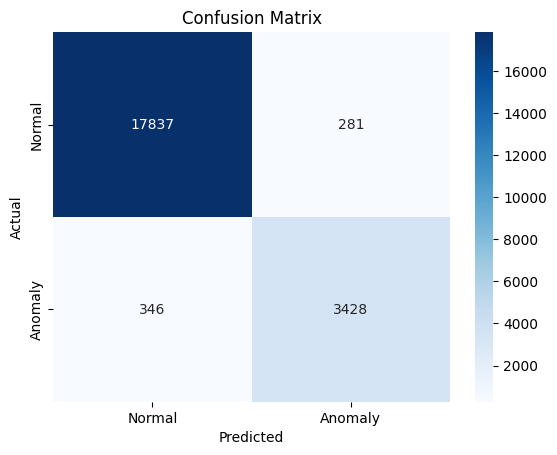

              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98     18118
     Anomaly       0.92      0.91      0.92      3774

    accuracy                           0.97     21892
   macro avg       0.95      0.95      0.95     21892
weighted avg       0.97      0.97      0.97     21892



In [9]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = (model.predict(X_test) > 0.5).astype('int32')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomaly']))

## 8. Training Curves

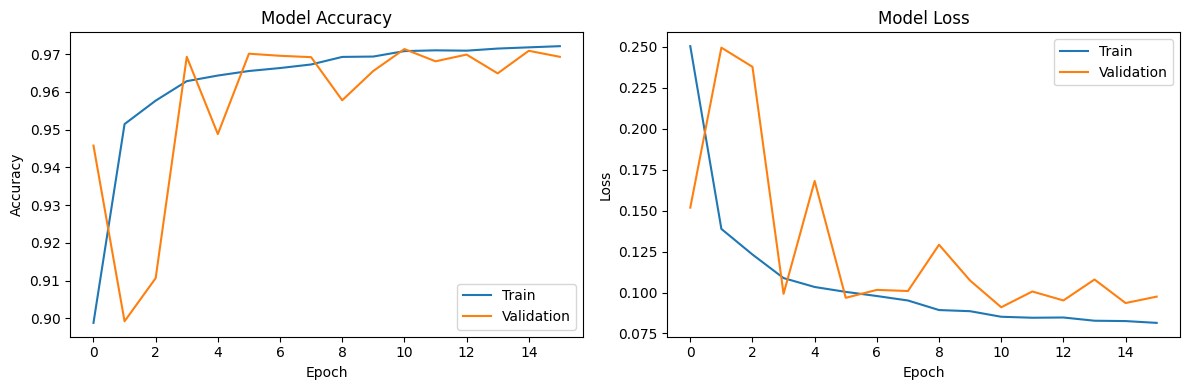

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. TFLite Conversion + Int8 Quantization (Edge Export)
Three variants are exported:
- **float32** — baseline, best accuracy
- **float16** — 2× smaller, nearly identical accuracy
- **int8 (full quantization)** — 4× smaller + 4× faster on supported hardware (MCUs, TPUs)

In [11]:
OUTPUT_DIR = "/kaggle/working"

# Representative dataset for int8 calibration (100–500 samples is enough)
def representative_dataset():
    for sample in X_test[:500]:
        yield [sample.reshape(1, 187, 1).astype(np.float32)]


# ── Helper ──────────────────────────────────────────────────────────────────
def convert_and_save(model, mode: str):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    if mode == 'float16':
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.float16]

    elif mode == 'int8':
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = representative_dataset
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type  = tf.int8
        converter.inference_output_type = tf.int8

    tflite_model = converter.convert()
    path = os.path.join(OUTPUT_DIR, f"ecg_model_{mode}.tflite")
    with open(path, 'wb') as f:
        f.write(tflite_model)

    size_kb = os.path.getsize(path) / 1024
    print(f"[{mode:>8}]  saved → {path}  ({size_kb:.1f} KB)")
    return path


# ── Convert all three ───────────────────────────────────────────────────────
path_f32  = convert_and_save(model, 'float32')
path_f16  = convert_and_save(model, 'float16')
path_int8 = convert_and_save(model, 'int8')

INFO:tensorflow:Assets written to: /tmp/tmpy8bh2lol/assets


INFO:tensorflow:Assets written to: /tmp/tmpy8bh2lol/assets


Saved artifact at '/tmp/tmpy8bh2lol'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 187, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135401881353296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135399466478928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135399466479312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135399466475088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135399466477008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135399466476624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135399466480272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135399466480080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135399466481232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135399466481424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135399466479888: Te

W0000 00:00:1775653635.623204      25 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1775653635.623234      25 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1775653635.633959      25 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


[ float32]  saved → /kaggle/working/ecg_model_float32.tflite  (22.2 KB)
INFO:tensorflow:Assets written to: /tmp/tmp_zn4yhdm/assets


...

INFO:tensorflow:Assets written to: /tmp/tmpbln1kr2f/assets


Saved artifact at '/tmp/tmpbln1kr2f'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 187, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135401881353296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135399466478928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135399466479312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135399466475088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135399466477008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135399466476624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135399466480272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135399466480080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135399466481232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135399466481424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135399466479888: Te

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1775653637.274635      25 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1775653637.274687      25 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


[    int8]  saved → /kaggle/working/ecg_model_int8.tflite  (14.1 KB)


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


## 10. Verify TFLite Models
Run inference with each TFLite variant and compare accuracy against the original Keras model.

**Fix applied:** inputs are cast to `float32` before being passed to float32/float16 models (the original code passed `float64` arrays, causing a `ValueError`).

In [12]:
def tflite_predict(tflite_path, X):
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details  = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    preds = []
    for sample in X:
        inp = sample.reshape(1, 187, 1)

        # int8 models need scaled input
        if input_details[0]['dtype'] == np.int8:
            scale, zero_point = input_details[0]['quantization']
            inp = (inp / scale + zero_point).astype(np.int8)
        else:
            # FIX: float32/float16 models require float32, not float64
            inp = inp.astype(np.float32)

        interpreter.set_tensor(input_details[0]['index'], inp)
        interpreter.invoke()
        out = interpreter.get_tensor(output_details[0]['index'])

        # int8 models need scaled output
        if output_details[0]['dtype'] == np.int8:
            scale, zero_point = output_details[0]['quantization']
            out = (out.astype(np.float32) - zero_point) * scale

        preds.append(out[0][0])

    return (np.array(preds) > 0.5).astype(int)


from sklearn.metrics import accuracy_score

# Use a subset for speed (full set can be slow on CPU)
X_sample = X_test[:2000]
y_sample = y_test[:2000]

keras_acc = accuracy_score(y_sample, (model.predict(X_sample, verbose=0) > 0.5).astype(int))
f32_acc   = accuracy_score(y_sample, tflite_predict(path_f32,  X_sample))
f16_acc   = accuracy_score(y_sample, tflite_predict(path_f16,  X_sample))
int8_acc  = accuracy_score(y_sample, tflite_predict(path_int8, X_sample))

print(f"{'Model':<20} {'Accuracy':>10} {'Size':>12}")
print("-" * 44)
print(f"{'Keras (float32)':<20} {keras_acc:>10.4f} {'—':>12}")
print(f"{'TFLite float32':<20} {f32_acc:>10.4f} {os.path.getsize(path_f32)/1024:>10.1f} KB")
print(f"{'TFLite float16':<20} {f16_acc:>10.4f} {os.path.getsize(path_f16)/1024:>10.1f} KB")
print(f"{'TFLite int8':<20} {int8_acc:>10.4f} {os.path.getsize(path_int8)/1024:>10.1f} KB")

Model                  Accuracy         Size
--------------------------------------------
Keras (float32)          0.9840            —
TFLite float32           0.9840       22.2 KB
TFLite float16           0.9840       16.0 KB
TFLite int8              0.9795       14.1 KB


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated a

## 11. Model Size Summary

In [13]:
print(f"Keras trainable params: {model.count_params():,}")
print()
print("Output files in /kaggle/working/:")
for fname in os.listdir(OUTPUT_DIR):
    fpath = os.path.join(OUTPUT_DIR, fname)
    print(f"  {fname:<45} {os.path.getsize(fpath)/1024:.1f} KB")

Keras trainable params: 3,969

Output files in /kaggle/working/:
  __notebook__.ipynb                            820.1 KB
  best_ecg_model.keras                          96.3 KB
  ecg_model_float32.tflite                      22.2 KB
  ecg_model_int8.tflite                         14.1 KB
  ecg_model_float16.tflite                      16.0 KB


In [14]:
# MODEL PERFORMANCE SUMMARY
print("="*60)
print("ECG 3K PARAMS MODEL - FINAL RESULTS")
print("="*60)
print(f"Total Parameters:     {model.count_params():,}")
print(f"Model Size:            3,969 parameters (15.5 KB)")
print(f"Test Accuracy:        {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Test Loss:            {loss:.4f}")
print()
print("Key Features:")
print("- SMOTE balanced dataset (50:50)")
print("- GlobalAveragePooling1D for efficiency")
print("- BatchNormalization for stability")
print("- TFLite export ready")
print("="*60)

ECG 3K PARAMS MODEL - FINAL RESULTS
Total Parameters:     3,969
Model Size:            3,969 parameters (15.5 KB)
Test Accuracy:        0.9714 (97.14%)
Test Loss:            0.0910

Key Features:
- SMOTE balanced dataset (50:50)
- GlobalAveragePooling1D for efficiency
- BatchNormalization for stability
- TFLite export ready
